# 03. 심화 실습 1: 조건부 엣지 + 루프

---

## 학습 목표

검색 결과가 부족하면 **검색어를 재작성해 자동으로 다시 검색**하는 에이전트를 만듭니다.  
이번 노트북에서 배우는 단 하나의 새로운 개념: **조건부 엣지 + 루프**

## 이전 노트북과 비교

```text
01_basic    START → [검색] → [추천] → END          (순차 실행)
02_parallel START → [A검색][B검색][C검색] → ...    (병렬 실행)

03_이번     START → [검색] → [평가] → (충분?) → [추천] → END
                                 ↓ 부족
                            [재작성] → [검색] (루프)
```

## 핵심 개념: 조건부 엣지

```python
# 일반 엣지: 항상 같은 노드로 이동
builder.add_edge("검색", "평가")

# 조건부 엣지: 상태에 따라 다른 노드로 이동
def decide(state) -> str:
    if state["is_sufficient"]:
        return "추천생성"      # ← 이쪽 or
    else:
        return "검색어재작성"   # ← 저쪽

builder.add_conditional_edges("결과평가", decide)
```

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

import os
import re
import requests
from html import unescape
from typing import TypedDict, List

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# LLM 모델 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("준비 완료")

준비 완료


In [2]:
def search_naver_shopping(query: str, display: int = 5, sort: str = "sim") -> list[dict]:
    """
    네이버 쇼핑 API로 상품을 검색한다.
    sort: sim(관련도), asc(낮은가격), dsc(높은가격)
    """
    url = "https://openapi.naver.com/v1/search/shop.json"

    # API 인증 헤더 설정
    headers = {
        "X-Naver-Client-Id":     os.environ["NAVER_CLIENT_ID"],
        "X-Naver-Client-Secret": os.environ["NAVER_CLIENT_SECRET"],
    }

    # 검색 파라미터 설정
    params = {"query": query, "display": display, "start": 1, "sort": sort}

    # API 호출
    resp = requests.get(url, headers=headers, params=params, timeout=10)
    resp.raise_for_status()  # HTTP 오류 시 예외 발생

    # 응답에서 상품 목록 추출
    result = []
    for item in resp.json().get("items", []):
        # HTML 태그와 특수문자 제거 (예: <b>상품명</b> → 상품명)
        clean_title = re.sub(r"<[^>]+>", "", unescape(item.get("title", "")))
        result.append({
            "title":  clean_title,
            "link":   item.get("link", ""),
            "lprice": int(item.get("lprice", 0) or 0),  # 최저가 (없으면 0)
            "mall":   item.get("mallName", ""),
        })
    return result

print("API 래퍼 정의 완료")

API 래퍼 정의 완료


---

## Step 1. State 정의

`search_query` 와 `retry_count` 가 이번 노트북의 핵심 필드입니다.

In [3]:
MAX_RETRY = 2  # 최대 재검색 횟수

class ConditionalShoppingState(TypedDict):
    question:      str        # 사용자 원본 질문 (입력, 변하지 않음)
    search_query:  str        # 실제 검색어 (루프마다 재작성될 수 있음)
    products:      List[dict] # 검색된 상품 목록
    is_sufficient: bool       # 결과가 충분한지 여부 → 분기 기준
    answer:        str        # 최종 추천 답변 (출력)
    retry_count:   int        # 재시도 횟수 (무한루프 방지)

print("State 필드:", list(ConditionalShoppingState.__annotations__.keys()))
print()
print("※ search_query: 처음엔 question과 같지만 재작성 노드에서 변경됨")
print("※ retry_count : MAX_RETRY 초과 시 루프 강제 종료")

State 필드: ['question', 'search_query', 'products', 'is_sufficient', 'answer', 'retry_count']

※ search_query: 처음엔 question과 같지만 재작성 노드에서 변경됨
※ retry_count : MAX_RETRY 초과 시 루프 강제 종료


---

## Step 2. 노드 정의 (4개)

```text
검색  →  결과평가  →  (분기)  →  추천생성
              ↑               ↓
         검색어재작성  ←────────
```

In [4]:
# ── 노드 1: 검색 ──────────────────────────────────────────────
def search_node(state: ConditionalShoppingState) -> dict:
    """search_query로 네이버 쇼핑을 검색한다 (첫 실행은 question 사용)"""
    # search_query가 비어 있으면 원본 질문을 검색어로 사용
    query = state.get("search_query") or state["question"]
    count = state.get("retry_count", 0) + 1
    print(f"  [검색 #{count}] '{query}'")

    # 네이버 쇼핑 API 호출
    products = search_naver_shopping(query, display=5)
    print(f"  [검색] {len(products)}개 수집")

    # retry_count는 몇 번째 검색인지 추적 (루프 횟수 제한용)
    return {"products": products, "retry_count": count}

In [5]:
# ── 노드 2: 결과평가 ──────────────────────────────────────────
def evaluate_node(state: ConditionalShoppingState) -> dict:
    """검색 결과가 추천에 충분한지 판단한다"""
    count      = len(state["products"])
    sufficient = count >= 3   # 3개 이상이면 충분하다고 판단

    print(f"  [결과평가] {count}개 → {'✅ 충분' if sufficient else '❌ 부족'}")
    return {"is_sufficient": sufficient}

In [6]:
# ── 노드 3: 검색어재작성 ──────────────────────────────────────
# 결과가 부족할 때 더 넓은 검색어를 생성하는 프롬프트
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", """검색 결과가 부족했습니다.
원본 질문의 의도를 유지하면서 네이버 쇼핑에서 더 많은 결과가 나올 수 있도록
더 넓고 일반적인 검색어로 재작성하세요.
검색어만 출력하세요."""),
    ("human", "원본 질문: {question}\n현재 검색어: {search_query}\n\n재작성:")
])

def rewrite_node(state: ConditionalShoppingState) -> dict:
    """결과 부족 시 더 넓은 검색어로 재작성한다"""
    # 현재 검색어 (없으면 원본 질문 사용)
    current = state.get("search_query") or state["question"]

    # 체인 정의: 프롬프트 → LLM → 텍스트 파서
    chain = rewrite_prompt | llm | StrOutputParser()

    # 체인 실행: LLM이 새로운 검색어를 생성
    new_query = chain.invoke({
        "question":     state["question"],
        "search_query": current
    }).strip()  # 앞뒤 공백 제거

    print(f"  [재작성] '{current}' → '{new_query}'")
    return {"search_query": new_query}

In [7]:
# ── 노드 4: 추천생성 ──────────────────────────────────────────
# 상품 추천 프롬프트
recommend_prompt = ChatPromptTemplate.from_messages([
    ("system", """아래 네이버 쇼핑 검색 결과를 바탕으로 상품을 추천하세요.

### 추천 상품
(순위, 상품명, 가격, 쇼핑몰, 링크)

### 구매 포인트
(가격대, 선택 시 유의사항 1~2줄)"""),
    ("human", "요청: {question}\n\n검색 결과:\n{products}")
])

def recommend_node(state: ConditionalShoppingState) -> dict:
    """검색된 상품으로 추천 답변을 생성한다"""
    print("  [추천생성] 작성 중...")

    # 상품 목록을 LLM이 읽기 쉬운 텍스트로 변환
    lines = []
    for i, p in enumerate(state["products"]):
        line = f"[{i+1}] {p['title'][:45]} | {p['lprice']:,}원 | {p['mall']} | {p['link']}"
        lines.append(line)
    products_text = "\n".join(lines)

    # 체인 정의: 프롬프트 → LLM → 텍스트 파서
    chain = recommend_prompt | llm | StrOutputParser()

    # 체인 실행: 질문과 상품 목록을 넣어 추천 생성
    answer = chain.invoke({
        "question": state["question"],
        "products": products_text
    })

    print("  [추천생성] 완료")
    return {"answer": answer}


print("노드 4개 정의 완료")

노드 4개 정의 완료


---

## Step 3. 라우팅 함수 & 그래프 조립

**라우팅 함수** 는 State를 보고 다음에 실행할 노드 이름을 반환합니다.

In [8]:
# ── 라우팅 함수 ──────────────────────────────────────────────
def decide_after_evaluate(state: ConditionalShoppingState) -> str:
    """결과평가 후 다음 노드를 결정한다"""
    if state["is_sufficient"]:
        # 결과가 충분하면 추천 생성으로 이동
        print("  [결정] 결과 충분 → 추천생성으로")
        return "추천생성"
    elif state.get("retry_count", 0) >= MAX_RETRY:
        # 최대 재시도 횟수를 초과하면 강제로 추천 생성
        print(f"  [결정] {MAX_RETRY}회 초과 → 추천생성 강제 진행")
        return "추천생성"
    else:
        # 결과가 부족하면 검색어를 재작성하고 다시 검색
        print("  [결정] 결과 부족 → 검색어 재작성 후 재검색")
        return "검색어재작성"


# ── 그래프 조립 ──────────────────────────────────────────────
builder = StateGraph(ConditionalShoppingState)

# 노드 등록
builder.add_node("검색",        search_node)
builder.add_node("결과평가",    evaluate_node)
builder.add_node("검색어재작성", rewrite_node)
builder.add_node("추천생성",    recommend_node)

# 일반 엣지: 항상 같은 노드로 이동
builder.add_edge(START,          "검색")
builder.add_edge("검색",         "결과평가")

# 조건부 엣지: 평가 결과에 따라 분기
builder.add_conditional_edges("결과평가", 
                              decide_after_evaluate,
                                {
                                    "추천생성": "추천생성", 
                                    "검색어재작성": "검색어재작성",
                                }
                            )

# 루프 엣지: 재작성 → 다시 검색 (이 엣지가 루프를 만듦)
builder.add_edge("검색어재작성", "검색")
builder.add_edge("추천생성",     END)

# 그래프 컴파일
app = builder.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


---

## Step 4. 그래프 시각화

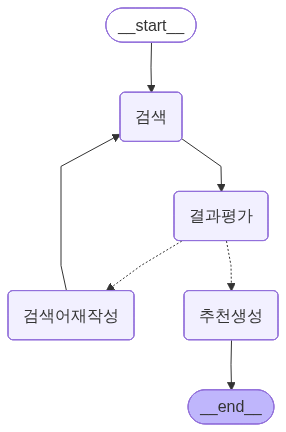

In [9]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print(app.get_graph().draw_ascii())

---

## Step 5. 실행 테스트

In [10]:
def run(question: str):
    print(f"\n{'='*55}")
    print(f"질문: {question}")
    print('='*55)

    # 초기 State 설정 후 그래프 실행
    result = app.invoke({
        "question":      question,
        "search_query":  "",        # 처음엔 비워둠 (search_node에서 question을 사용)
        "products":      [],
        "is_sufficient": False,
        "answer":        "",
        "retry_count":   0,
    })

    print(f"\n[검색 횟수: {result['retry_count']}회 | 수집: {len(result['products'])}개]")
    print(f"\n{result['answer']}")


# 테스트 1: 일반 검색 (1회로 충분한 경우)
run("무선 마우스 추천")


질문: 무선 마우스 추천
  [검색 #1] '무선 마우스 추천'
  [검색] 5개 수집
  [결과평가] 5개 → ✅ 충분
  [결정] 결과 충분 → 추천생성으로
  [추천생성] 작성 중...
  [추천생성] 완료

[검색 횟수: 1회 | 수집: 5개]

### 추천 상품

1. **아이리버 무선 버티컬 마우스 EQwear-EV15 블랙**
   - 가격: 24,900원
   - 쇼핑몰: 네이버
   - [구매 링크](https://search.shopping.naver.com/catalog/52997919797)

2. **로지텍 로지텍G G304 LIGHTSPEED WIRELESS 정품, 블랙**
   - 가격: 36,790원
   - 쇼핑몰: 네이버
   - [구매 링크](https://search.shopping.naver.com/catalog/55596555372)

3. **로지텍 M331 무소음 무선 마우스 정품, 블랙**
   - 가격: 25,500원
   - 쇼핑몰: 네이버
   - [구매 링크](https://search.shopping.naver.com/catalog/56500300652)

4. **맥스틸 무소음 무선 버티컬 마우스 저소음 인체공학 사무용 노트북 맥북 갤럭시북 호**
   - 가격: 9,900원
   - 쇼핑몰: 디어다니
   - [구매 링크](https://smartstore.naver.com/main/products/9543735910)

5. **로지텍 MX MASTER 4 정품, 그래파이트**
   - 가격: 179,000원
   - 쇼핑몰: 네이버
   - [구매 링크](https://search.shopping.naver.com/catalog/57537711903)

### 구매 포인트
- **가격대**: 9,900원부터 179,000원까지 다양한 가격대의 제품이 있습니다. 예산에 맞춰 선택하세요.
- **유의사항**: 무선 마우스는 사용 용도에 따라 선택하는 것이 중요합니다. 게임용, 사무용, 인체공학적 디자인

In [11]:
# 테스트 2: 구체적인 질문 (재검색이 발생할 수도 있음)
run("핑크색 고양이 모양 블루투스 스피커")


질문: 핑크색 고양이 모양 블루투스 스피커
  [검색 #1] '핑크색 고양이 모양 블루투스 스피커'
  [검색] 5개 수집
  [결과평가] 5개 → ✅ 충분
  [결정] 결과 충분 → 추천생성으로
  [추천생성] 작성 중...
  [추천생성] 완료

[검색 횟수: 1회 | 수집: 5개]

### 추천 상품
1. **귀여운 블루투스 소형 핑크색 강력한 고양이 인테리어 우퍼 무선 동물 EDIFIER**
   - 가격: 61,400원
   - 쇼핑몰: 쿠팡
   - 링크: [구매하기](https://link.coupang.com/re/PCSNAVERPCSDP?pageKey=8754994439&ctag=8754994439&lptag=I25452579129&itemId=25452579129&vendorItemId=93111215613&spec=10305199)

2. **핑크 미니 레트로 LP판 레코드판 모양 블루투스 스피커 귀여운 차박 캠핑 감성 휴**
   - 가격: 46,900원
   - 쇼핑몰: 핑크덕후 스토어
   - 링크: [구매하기](https://smartstore.naver.com/main/products/8334516156)

3. **산리오 헬로키티 귀여운 캐릭터 블루투스 스피커 무선 노래방 마이크 세트**
   - 가격: 52,900원
   - 쇼핑몰: 주식회사 로이체
   - 링크: [구매하기](https://smartstore.naver.com/main/products/11961302291)

### 구매 포인트
- **가격대**: 22,700원부터 149,100원까지 다양하므로 예산에 맞춰 선택할 수 있습니다.
- **선택 시 유의사항**: 디자인과 기능(우퍼, 노래방 마이크 등)을 고려하여 본인의 용도에 맞는 제품을 선택하세요.


In [12]:
# stream(): 조건부 분기와 루프 실행 과정 확인
print("=== stream()으로 조건부 실행 흐름 추적 ===")

for event in app.stream({
    "question":      "3만원 이하 미니 선풍기",
    "search_query":  "",
    "products":      [],
    "is_sufficient": False,
    "answer":        "",
    "retry_count":   0,
}):
    # event는 {노드이름: 해당 노드의 출력} 형태
    node_name = list(event.keys())[0]
    output    = event[node_name]

    if "products" in output:
        print(f"  [{node_name}] 상품 {len(output['products'])}개 수집")
    elif "is_sufficient" in output:
        print(f"  [{node_name}] 충분 여부 = {output['is_sufficient']}")
    elif "search_query" in output:
        print(f"  [{node_name}] 새 검색어 = '{output['search_query']}'")
    elif "answer" in output:
        print(f"  [{node_name}] 추천 완료")

=== stream()으로 조건부 실행 흐름 추적 ===
  [검색 #1] '3만원 이하 미니 선풍기'
  [검색] 5개 수집
  [검색] 상품 5개 수집
  [결과평가] 5개 → ✅ 충분
  [결정] 결과 충분 → 추천생성으로
  [결과평가] 충분 여부 = True
  [추천생성] 작성 중...
  [추천생성] 완료
  [추천생성] 추천 완료


In [13]:
# stream(): 최종 추천 결과만 출력
final_answer = ""

for event in app.stream({
    "question":          "가성비 좋은 기계식 키보드",
    "keyword_a":         "",
    "keyword_b":         "",
    "all_products":      [],
    "filtered_products": [],
    "is_sufficient":     False,
    "answer":            "",
    "retry_count":       0,
}):
    for node_name, output in event.items():
        if "answer" in output:
            final_answer = output["answer"]

print(final_answer)

  [검색 #1] '가성비 좋은 기계식 키보드'
  [검색] 5개 수집
  [결과평가] 5개 → ✅ 충분
  [결정] 결과 충분 → 추천생성으로
  [추천생성] 작성 중...
  [추천생성] 완료
### 추천 상품
1. **앱코 게이밍 기계식 키보드 풀배열 유선 적축 K560 해커 사무실 사무용 게임용**
   - 가격: 30,900원
   - 쇼핑몰: 드림팩토리샵
   - 링크: [구매하기](https://smartstore.naver.com/main/products/9348516802)

2. **게이밍 기계식 키보드 앱코 K640 청축 게임용 피시방 저소음 사무실 사무용 풀배**
   - 가격: 42,000원
   - 쇼핑몰: 드림팩토리샵
   - 링크: [구매하기](https://smartstore.naver.com/main/products/5644036525)

3. **GDEVIL G812 METEOR 파스텔 기계식 키보드 사무용 게이밍 저소음 MA**
   - 가격: 49,800원
   - 쇼핑몰: GDEVIL
   - 링크: [구매하기](https://smartstore.naver.com/main/products/11424351788)

### 구매 포인트
- **가격대**: 30,900원부터 시작하여 49,800원까지 다양한 옵션이 있습니다. 가성비를 중시하는 분들에게 적합합니다.
- **선택 시 유의사항**: 키보드의 스위치 종류(청축, 적축 등)에 따라 타건감과 소음이 다르므로, 사용 용도에 맞는 스위치를 선택하는 것이 중요합니다.


---

## 핵심 정리

```python
# 조건부 엣지 + 루프 핵심 패턴

# 1. 라우팅 함수: 상태에 따라 다음 노드 결정
def decide_after_evaluate(state) -> str:
    if state["is_sufficient"]:
        return "추천생성"       # 조건 충족 → 앞으로
    elif state["retry_count"] >= MAX_RETRY:
        return "추천생성"       # 한계 도달 → 강제 종료
    else:
        return "검색어재작성"   # 조건 미충족 → 루프

# 2. 조건부 엣지 연결
builder.add_conditional_edges("결과평가", decide_after_evaluate)

# 3. 루프 만들기: 재작성 후 다시 검색으로
builder.add_edge("검색어재작성", "검색")  # ← 이 엣지가 루프를 만듦

# 4. 체인 실행 (2단계로 분리)
chain = rewrite_prompt | llm | StrOutputParser()
new_query = chain.invoke({"question": ..., "search_query": ...}).strip()
```

| 노드 | 역할 |
|---|---|
| 검색 | 현재 search_query로 API 호출 |
| 결과평가 | 상품 수 기준으로 충분 여부 판단 |
| 검색어재작성 | LLM으로 더 넓은 검색어 생성 |
| 추천생성 | 최종 상품 추천 리포트 작성 |

→ 다음: **전체 통합 쇼핑 추천 Agent** (04_advanced_shopping_agent.ipynb)